In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates 

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

In [2]:
fad = pd.read_csv('h4_facebook_ads_data.csv')

In [3]:
#  fad['ad_date'] = pd.to_datetime(fad['ad_date']) -- інший спосіб фільтрації даних за 2021 рік з перетворенням в формат дати
#  y2021df = fad[fad['ad_date'].dt.year==2021]

In [4]:
y2021df = fad[fad['ad_date'].between('2021-01-01', '2021-12-31')].sort_values('ad_date')

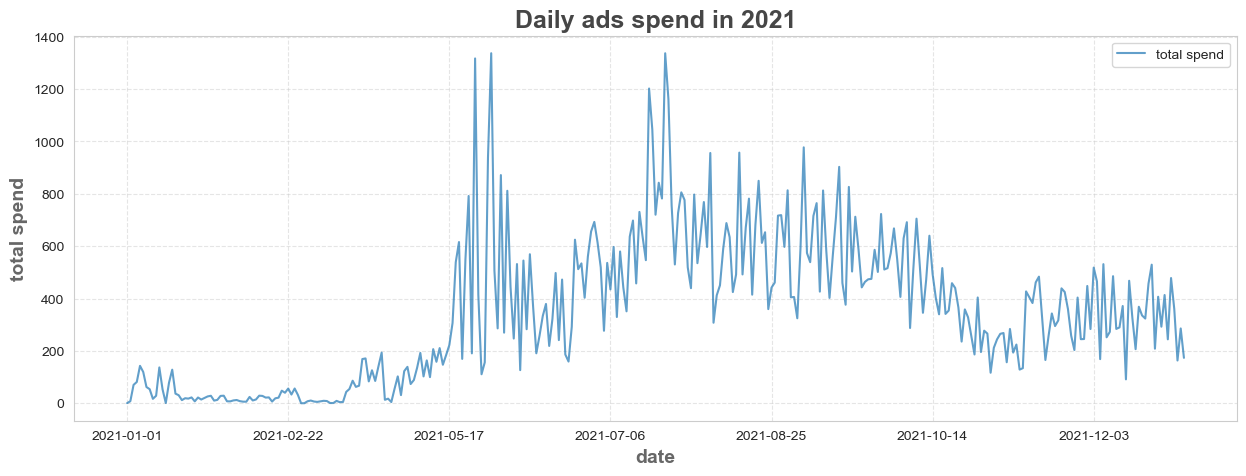

In [5]:
y2021df.groupby('ad_date')['total_spend'].sum().plot(label = 'total spend', alpha = 0.7)

plt.grid(True, linestyle = '--', alpha = 0.5)
plt.title('Daily ads spend in 2021', fontsize = 18, fontweight = 'bold', alpha = 0.85)
plt.xlabel('date', fontsize = 14, fontweight = 'bold', alpha = 0.7)
plt.ylabel('total spend', fontsize = 14, fontweight = 'bold', alpha = 0.7)
plt.legend()

plt.show()

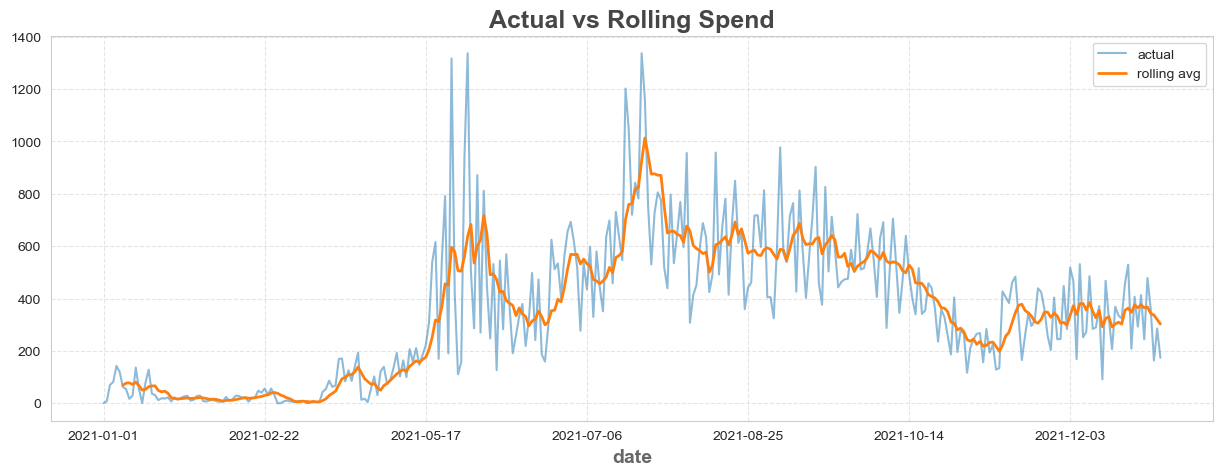

In [6]:
daily_spend = y2021df.groupby('ad_date')['total_spend'].sum()
rolling_spend = daily_spend.rolling(window = 7).mean()

plt.figure()
daily_spend.plot(label = 'actual', alpha = 0.5)
rolling_spend.plot(label = 'rolling avg', linewidth = 2)

plt.title('Actual vs Rolling Spend', fontsize = 18, fontweight = 'bold', alpha = 0.85)
plt.xlabel('date', fontsize = 14, fontweight = 'bold', alpha = 0.7)
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.legend()

plt.show()

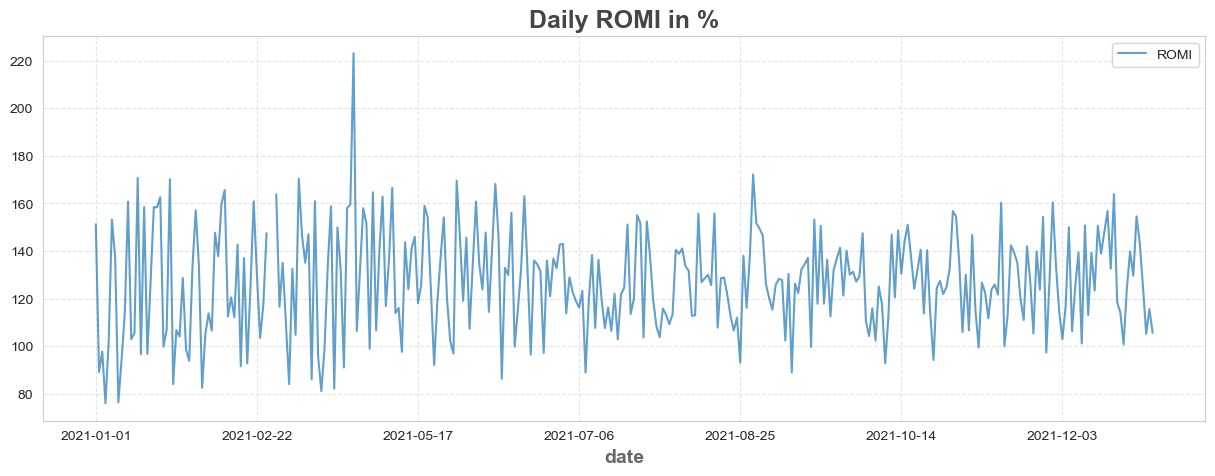

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

daily_romi = y2021df.groupby('ad_date').agg({'total_spend' : 'sum', 'total_value' : 'sum'})
daily_romi['ROMI'] = (daily_romi['total_value'] / daily_romi['total_spend'] * 100).round(2)

daily_romi['ROMI'].plot(alpha = 0.7)

plt.title('Daily ROMI in %', fontsize = 18, fontweight = 'bold', alpha = 0.85)
plt.xlabel('date', fontsize = 14, fontweight = 'bold', alpha = 0.7)
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.legend()

plt.show()

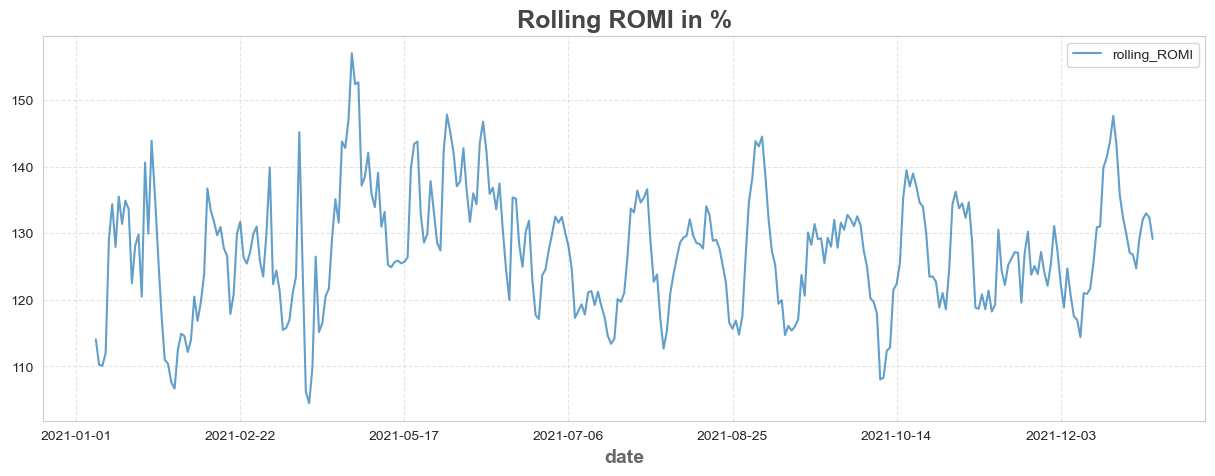

In [8]:
daily_romi = y2021df.groupby('ad_date').agg({'total_spend' : 'sum', 'total_value' : 'sum'}).rolling(7).sum()
daily_romi['rolling_ROMI'] = (daily_romi['total_value'] / daily_romi['total_spend'] * 100).round(2)

daily_romi['rolling_ROMI'].plot(alpha = 0.7)

plt.title('Rolling ROMI in %', fontsize = 18, fontweight = 'bold', alpha = 0.85)
plt.xlabel('date', fontsize = 14, fontweight = 'bold', alpha = 0.7)
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.legend()

plt.show()

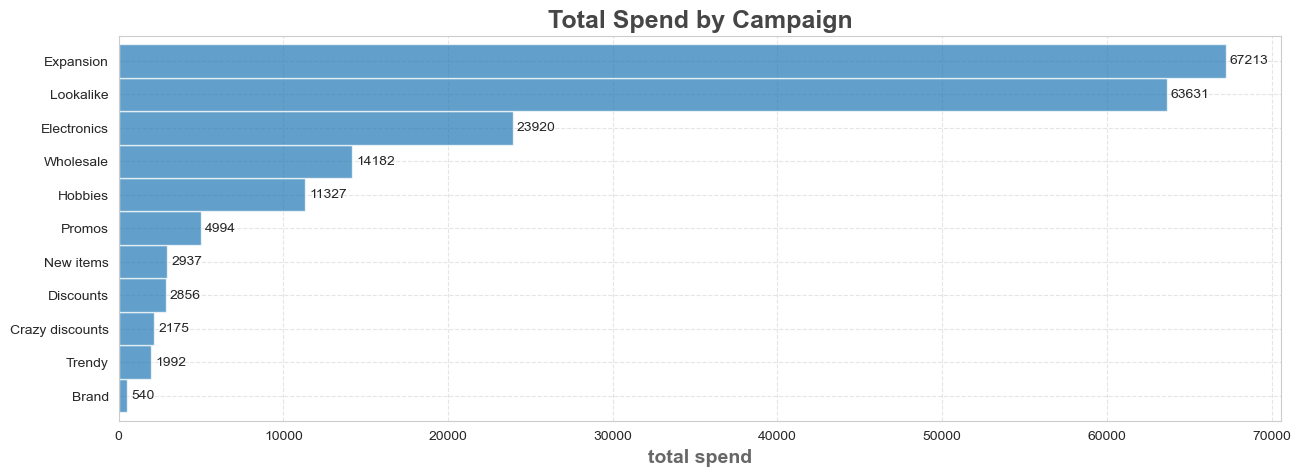

In [9]:
campaign_spend = fad.groupby('campaign_name')['total_spend'].sum().sort_values().plot(kind = 'barh', width = 1, alpha = 0.7)

plt.title('Total Spend by Campaign', fontsize = 18, fontweight = 'bold', alpha = 0.85)
plt.xlabel('total spend', fontsize = 14, fontweight = 'bold', alpha = 0.7)
plt.ylabel('')
plt.grid(True, linestyle = '--', alpha = 0.5)

for i in campaign_spend.containers:
    campaign_spend.bar_label(i, fmt='%.0f', padding = 3)
    
plt.show()

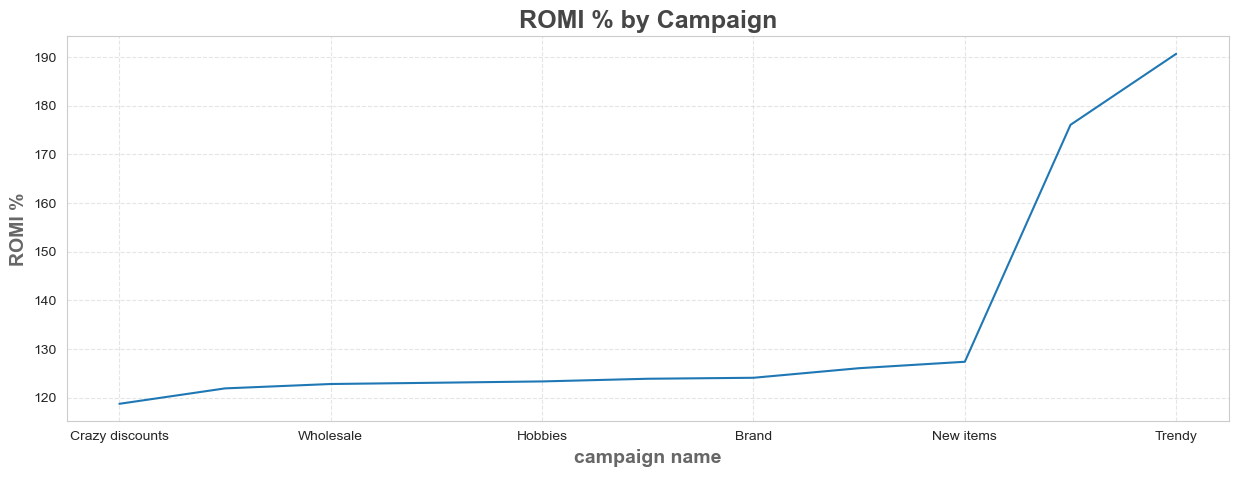

In [10]:
camp_romi = fad.groupby('campaign_name')[['total_spend', 'total_value']].sum()
camp_romi['ROMI'] = (camp_romi['total_value'] / camp_romi['total_spend'] * 100).round(2).sort_values().plot()

plt.title('ROMI % by Campaign', fontsize = 18, fontweight = 'bold', alpha = 0.85)
plt.xlabel('campaign name', fontsize = 14, fontweight = 'bold', alpha = 0.7)
plt.ylabel('ROMI %', fontsize = 14, fontweight = 'bold', alpha = 0.7)
plt.grid(True, linestyle = '--', alpha = 0.5)

plt.show()

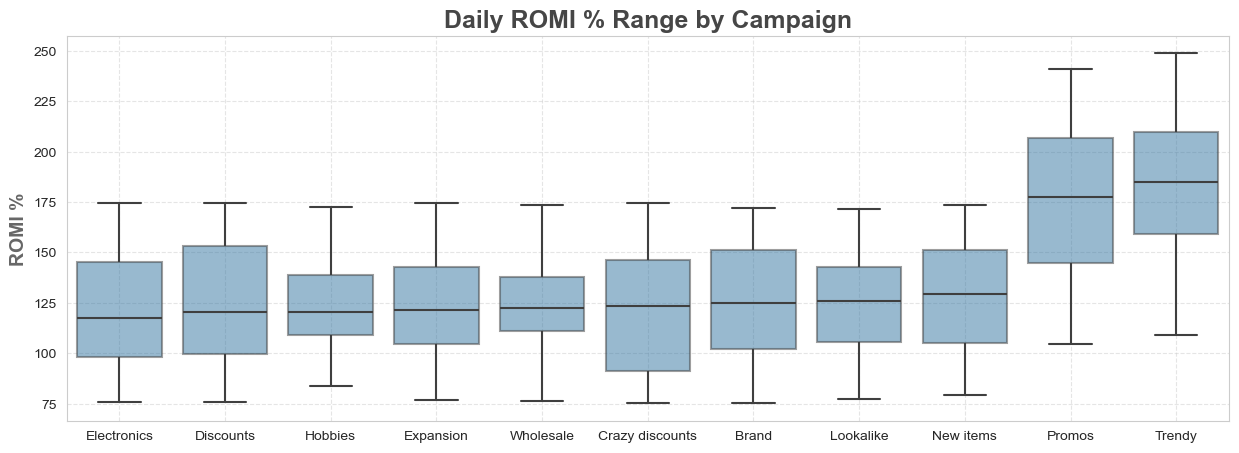

In [11]:
daily_romi_range = fad.groupby(['ad_date', 'campaign_name'])[['total_spend', 'total_value']].sum()
daily_romi_range['ROMI'] = (daily_romi_range['total_value'] / daily_romi_range['total_spend'] * 100).round(2)
daily_romi_range = daily_romi_range.reset_index()
orderby = daily_romi_range.groupby('campaign_name')['ROMI'].median().sort_values().index

sns.boxplot(data = daily_romi_range, x = 'campaign_name', y = 'ROMI', linewidth=1.5, order = orderby, boxprops=dict(alpha=0.5))

plt.title('Daily ROMI % Range by Campaign', fontsize = 18, fontweight = 'bold', alpha = 0.85)
plt.ylabel('ROMI %', fontsize = 14, fontweight = 'bold', alpha = 0.7)
plt.xlabel('')
plt.grid(True, linestyle = '--', alpha = 0.5)

plt.show()

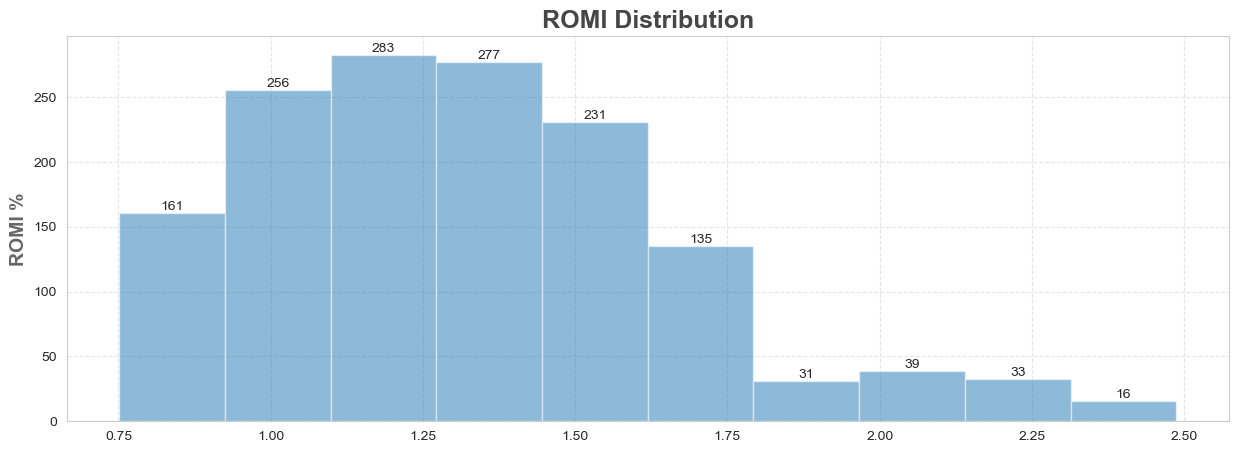

In [12]:
ax = fad['romi'].plot(kind = 'hist', alpha = 0.5)

for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom')
        
plt.title('ROMI Distribution', fontsize = 18, fontweight = 'bold', alpha = 0.85)
plt.ylabel('ROMI %', fontsize = 14, fontweight = 'bold', alpha = 0.7)
plt.xlabel('')
plt.grid(True, linestyle = '--', alpha = 0.5)

plt.show()

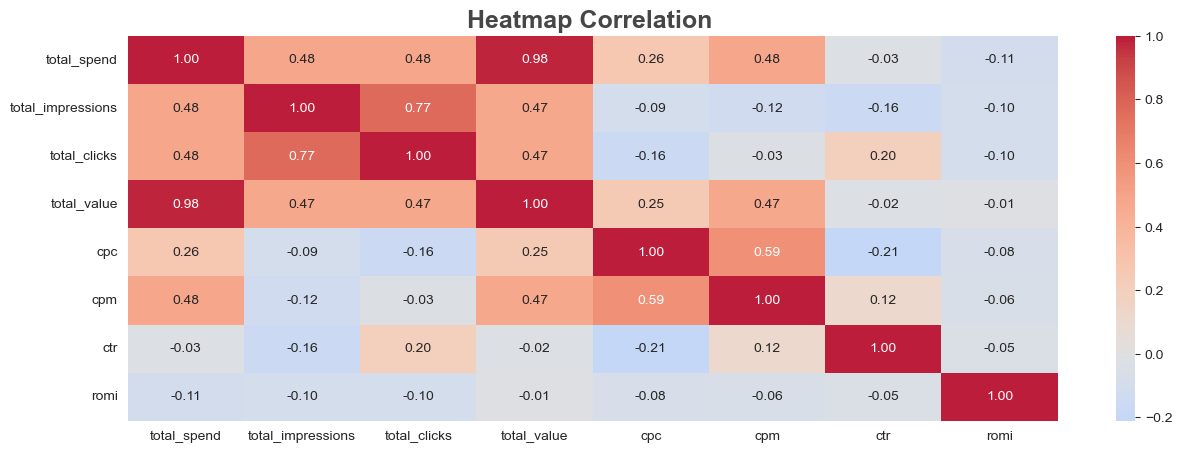

In [13]:
corr = fad[['total_spend', 'total_impressions', 'total_clicks', 'total_value', 'cpc', 'cpm', 'ctr', 'romi']].corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm', fmt = '.2f', center = 0, alpha=0.9)

plt.title('Heatmap Correlation ', fontsize = 18, fontweight = 'bold', alpha = 0.85)
plt.grid(False)

plt.show()

##### Які показники мають найвищу та найнижчу кореляцію?  
Найвищу кореляцію має **total value** від **total spend**. Найнижчу кореляцію мають **romi** від **total spend** та інших показників.  
##### З чим корелює "total_value"?  
Найбільше **total value** корелює з **total spend**. Також бачимо помірну залежність **total value** від **total impressions** і **total clicks**.  

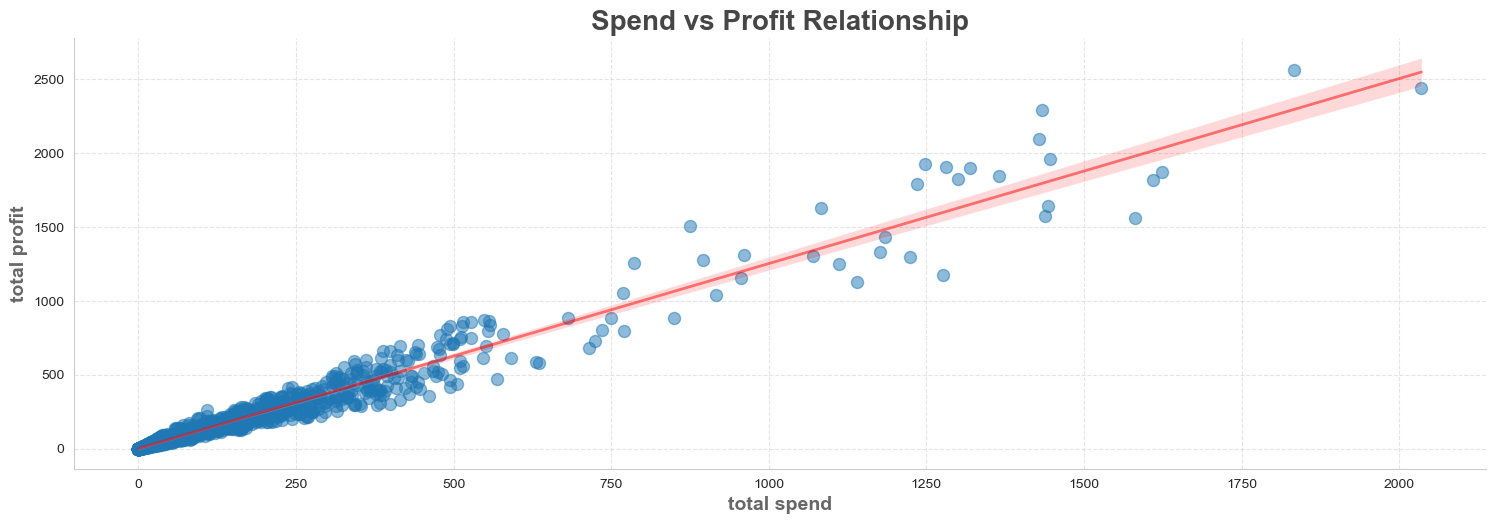

In [15]:
sns.lmplot(x = 'total_spend', y = 'total_value', data = fad, height=5, aspect=3, scatter_kws={'s': 75, 'alpha': 0.5},
                                                                                line_kws={'color': 'red', 'linewidth': 2, 'alpha': 0.5})
plt.title('Spend vs Profit Relationship', fontsize = 20, fontweight = 'bold', alpha = 0.85)
plt.xlabel('total spend', fontsize = 14, fontweight = 'bold', alpha = 0.7)
plt.ylabel('total profit', fontsize = 14, fontweight = 'bold', alpha = 0.7)
plt.grid(True, linestyle = '--', alpha = 0.5)

plt.show()